In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(r'C:\CODING\MACHINE LEARNING\insurance.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

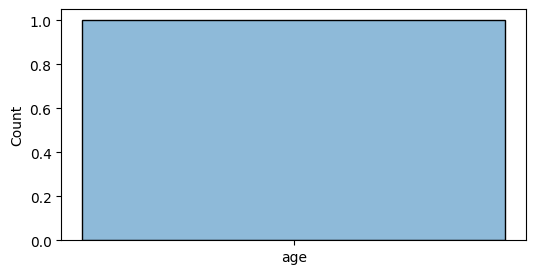

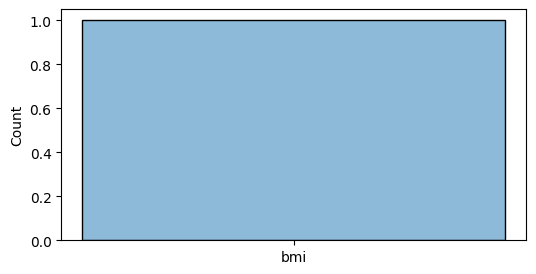

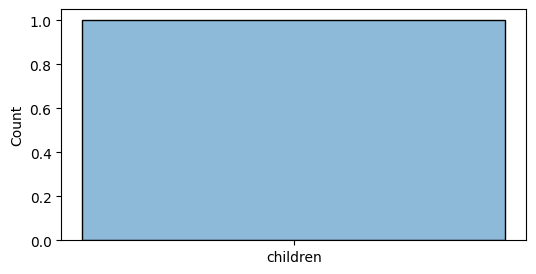

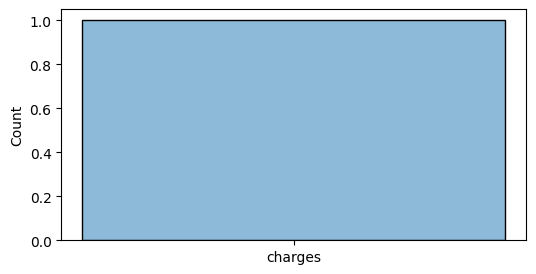

In [ ]:
numeric_columns = ['age',  'bmi', 'children','charges']

for col in numeric_columns:
    plt.figure(figsize=(6,3))
    sns.histplot([col],kde=True,bins=10)

<Axes: xlabel='smoker', ylabel='count'>

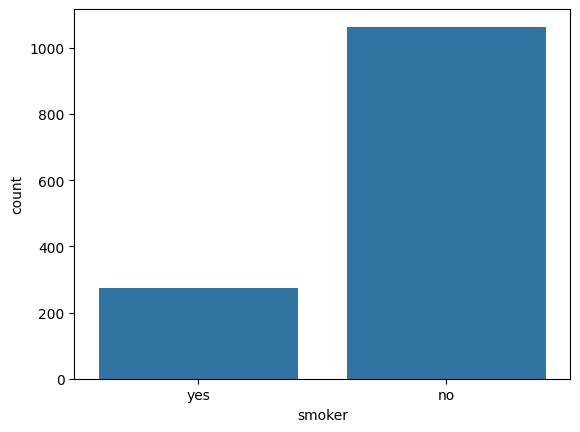

In [ ]:
sns.countplot( x= df['smoker'])

<Axes: xlabel='sex', ylabel='count'>

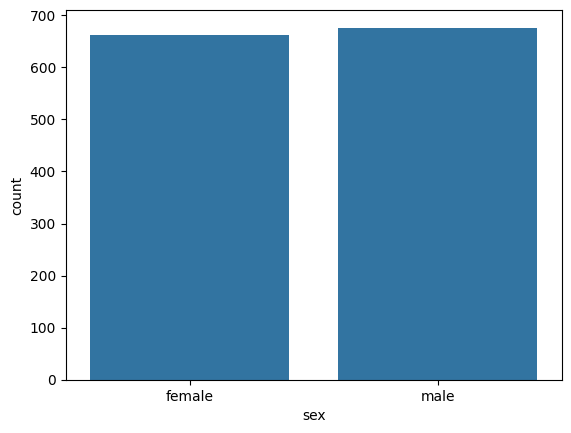

In [ ]:
sns.countplot( x=df['sex'])

<Axes: >

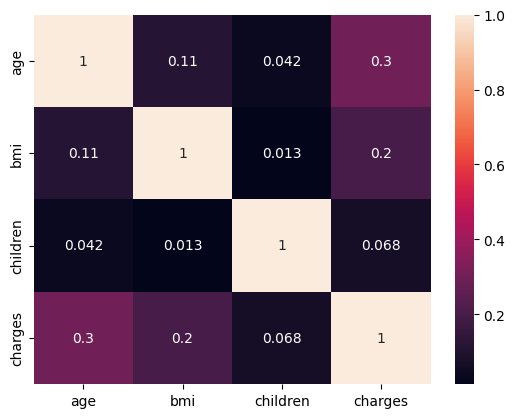

In [ ]:
plt.Figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

DATA CLEANING AND PRE PROCESSING 

In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.shape

(1338, 7)

In [ ]:
df_cleaned.drop_duplicates(inplace=True)

In [ ]:
df_cleaned.shape

(1337, 7)

In [ ]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df_cleaned.value_counts('sex')

sex
male      675
female    662
Name: count, dtype: int64

In [ ]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0, "female" :1})

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.value_counts('smoker')

smoker
no     1063
yes     274
Name: count, dtype: int64

In [ ]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"yes" : 0, "no": 1})

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [ ]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [ ]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False


In [ ]:
df_cleaned = df_cleaned.astype(float)

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19.0,1.0,27.900,0.0,0.0,16884.92400,0.0,0.0,1.0
1,18.0,0.0,33.770,1.0,1.0,1725.55230,0.0,1.0,0.0
2,28.0,0.0,33.000,3.0,1.0,4449.46200,0.0,1.0,0.0
3,33.0,0.0,22.705,0.0,1.0,21984.47061,1.0,0.0,0.0
4,32.0,0.0,28.880,0.0,1.0,3866.85520,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50.0,0.0,30.970,3.0,1.0,10600.54830,1.0,0.0,0.0
1334,18.0,1.0,31.920,0.0,1.0,2205.98080,0.0,0.0,0.0
1335,18.0,1.0,36.850,0.0,1.0,1629.83350,0.0,1.0,0.0
1336,21.0,1.0,25.800,0.0,1.0,2007.94500,0.0,0.0,1.0


FEATURE ENGINERRRING AND EXTRACTION

MEANS ADDING NEW ROWS AND COLUMNS 

<Axes: xlabel='bmi', ylabel='Count'>

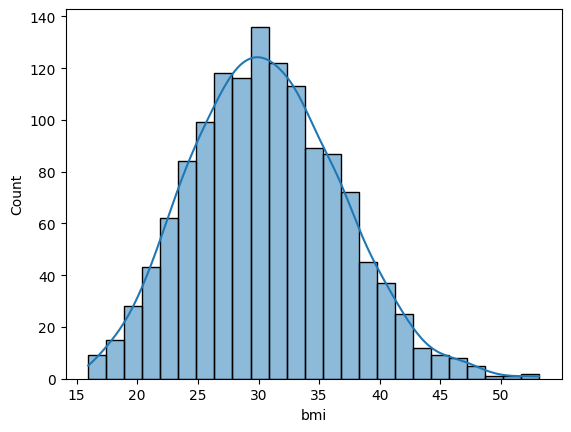

In [ ]:
sns.histplot(df['bmi'],kde=True)

In [ ]:
df_cleaned['bmi_cateogry'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,29.4,float('inf')],
    labels=['underweight','normal', 'overweight']
)

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogry
0,19.0,1.0,27.900,0.0,0.0,16884.92400,0.0,0.0,1.0,normal
1,18.0,0.0,33.770,1.0,1.0,1725.55230,0.0,1.0,0.0,overweight
2,28.0,0.0,33.000,3.0,1.0,4449.46200,0.0,1.0,0.0,overweight
3,33.0,0.0,22.705,0.0,1.0,21984.47061,1.0,0.0,0.0,normal
4,32.0,0.0,28.880,0.0,1.0,3866.85520,1.0,0.0,0.0,normal


In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogry
0,19.0,1.0,27.900,0.0,0.0,16884.92400,0.0,0.0,1.0,normal
1,18.0,0.0,33.770,1.0,1.0,1725.55230,0.0,1.0,0.0,overweight
2,28.0,0.0,33.000,3.0,1.0,4449.46200,0.0,1.0,0.0,overweight
3,33.0,0.0,22.705,0.0,1.0,21984.47061,1.0,0.0,0.0,normal
4,32.0,0.0,28.880,0.0,1.0,3866.85520,1.0,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...
1333,50.0,0.0,30.970,3.0,1.0,10600.54830,1.0,0.0,0.0,overweight
1334,18.0,1.0,31.920,0.0,1.0,2205.98080,0.0,0.0,0.0,overweight
1335,18.0,1.0,36.850,0.0,1.0,1629.83350,0.0,1.0,0.0,overweight
1336,21.0,1.0,25.800,0.0,1.0,2007.94500,0.0,0.0,1.0,normal


In [ ]:

# One-hot encode a single column
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_cateogry'], drop_first=True)


In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogry_normal,bmi_cateogry_overweight
0,19.0,1.0,27.900,0.0,0.0,16884.92400,0.0,0.0,1.0,True,False
1,18.0,0.0,33.770,1.0,1.0,1725.55230,0.0,1.0,0.0,False,True
2,28.0,0.0,33.000,3.0,1.0,4449.46200,0.0,1.0,0.0,False,True
3,33.0,0.0,22.705,0.0,1.0,21984.47061,1.0,0.0,0.0,True,False
4,32.0,0.0,28.880,0.0,1.0,3866.85520,1.0,0.0,0.0,True,False


In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogry_normal,bmi_cateogry_overweight
0,19,1,27,0,0,16884,0,0,1,1,0
1,18,0,33,1,1,1725,0,1,0,0,1
2,28,0,33,3,1,4449,0,1,0,0,1
3,33,0,22,0,1,21984,1,0,0,1,0
4,32,0,28,0,1,3866,1,0,0,1,0


In [ ]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cateogry_normal', 'bmi_cateogry_overweight'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogry_normal,bmi_cateogry_overweight
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0,1,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,1,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,1,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,1,0,0,1,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,1,0,0,1,0


In [ ]:
from scipy.stats import pearsonr

selected_features = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cateogry_normal', 'bmi_cateogry_overweight']
      
correlation = {
    featue : pearsonr(df_cleaned[featue],df_cleaned['charges'])[0]
    for featue in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()),columns=['FEATURE','PEARSON CORRELATION'])
correlation_df.sort_values(by= 'PEARSON CORRELATION',ascending=True)


,FEATURE,PEARSON CORRELATION
4,smoker,-0.787234
9,bmi_cateogry_normal,-0.177971
1,sex,-0.058046
8,region_southwest,-0.043637
6,region_northwest,-0.038695
3,children,0.067390
7,region_southeast,0.073577
10,bmi_cateogry_overweight,0.189218
2,bmi,0.196236
0,age,0.298309


In [ ]:


cat_features = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cateogry_normal', 'bmi_cateogry_overweight']

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges_bin'],q = 4,labels=False)
chi2_results = {}


for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    
    chi2_stat, p_val, _, _ =chi2_contingency(contingency)
    
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1.0, 2.0, 3.0], dtype='float64', name='charges_bin').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges_bin'],q = 4,labels=False)
chi2_results = {}


for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    
    chi2_stat, p_val, _, _ =chi2_contingency(contingency)
    
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1.0, 2.0, 3.0], dtype='float64', name='charges_bin').
You can drop duplicate edges by setting the 'duplicates' kwarg